## Fine tune BabyGPT with tinystories dataset

In [1]:
!pip install -q --upgrade bitsandbytes==0.48.2 trl==0.25.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 46.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 53.3 MB/s eta 0:00:00


In [2]:
import os
import math
from tqdm import tqdm
from huggingface_hub import login
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, set_seed, BitsAndBytesConfig
from datasets import load_dataset, Dataset, DatasetDict
import wandb
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from datetime import datetime
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import numpy as np

In [3]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
# elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
#     device = "mps"
print(f"using device: {device}")
device_type = "cuda" if device.startswith("cuda") else "cpu"

using device: cuda


In [3]:
# from google.colab import drive
# import os
# drive.mount('/content/drive')

# notebook_dir = "/content/drive/MyDrive/Colab_Notebooks"

In [4]:
load_dotenv()
wandb.login(key="") # removed in public repo
from huggingface_hub import login
hf_token = "" # removed in public repo
login(hf_token, add_to_git_credential=True)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: greygreygreat (Overfit&Coupled) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [34]:
BASE_MODEL = "littleBallOfFur/baby-gpt-base"
PROJECT_NAME = "baby-gpt-sft-tinystories"
RUN_NAME =  f"{datetime.now():%Y-%m-%d_%H.%M.%S}"
PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"

HUB_SUFFIX = "0424" #RUN_NAME
HUB_MODEL_NAME = f"littleBallOfFur/{PROJECT_NAME}-{HUB_SUFFIX}"

DATASET_NAME = "karpathy/tinystories-gpt4-clean"


## Load base model and tokenizer from hugging face

In [6]:
base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL,trust_remote_code=True)
# base_model.to(device)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
base_model.config.pad_token_id = tokenizer.pad_token_id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/584 [00:00<?, ?B/s]

babygpt_model.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/littleBallOfFur/baby-gpt-base:
- babygpt_model.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/652M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
base_model.eval()
prompt = "once upon a time there was a cat "
input = tokenizer(prompt,return_tensors='pt')
output = base_model.generate(**input, max_length=32, do_sample=True, top_k=50)
tokenizer.decode(output[0])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'once upon a time there was a cat urn urn.\nWe have to see that in all of them, they are all pretty much like their owners'

#### alternatively, try real gpt2 model

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained("gpt2")
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
base_model.config.pad_token_id = tokenizer.pad_token_id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
message = "As a language model, I can "
input = tokenizer.encode(message, return_tensors = 'pt')

base_model.eval()
output = base_model.generate(input,max_new_tokens=32,do_sample=True,
    top_k=50,
    top_p=0.95)
tokenizer.decode(output[0])

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


"As a language model, I can \xa0remember some of the ways in which the language models are applied.\xa0 One example would be how it's designed to be the most widely used language for an"

## dataset

In [8]:
raw_dataset = load_dataset(DATASET_NAME)

README.md: 0.00B [00:00, ?B/s]

tinystories_gpt4_clean.parquet:   0%|          | 0.00/673M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2732634 [00:00<?, ? examples/s]

In [28]:
split_1 = raw_dataset['train'].train_test_split(test_size=0.2, seed=42)
train_dataset = split_1["train"]
split_2 = split_1["test"].train_test_split(test_size=0.5, seed=42)
test_dataset = split_2["test"]
val_dataset = split_2["train"]
len(train_dataset), len(val_dataset),len(test_dataset)




(2186107, 273263, 273264)

In [29]:
MAX_TOKENS = 256
def keep_short(batch):
    texts = batch["text"]
    lengths = [
        len(ids)
        for ids in tokenizer(texts, add_special_tokens=True)["input_ids"]
    ]
    return [n <= MAX_TOKENS for n in lengths]

train_dataset = train_dataset.select(range(220000)).filter(keep_short, batched=True)
val_dataset = val_dataset.select(range(5100)).filter(keep_short, batched = True)
# test_dataset = test_dataset.filter(keep_short, batched = True)

len(train_dataset), len(val_dataset),len(test_dataset)


Filter:   0%|          | 0/220000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5100 [00:00<?, ? examples/s]

(195745, 4557, 273264)

## Training 

In [30]:
EPOCHS = 1 
BATCH_SIZE = 64
MAX_SEQUENCE_LENGTH = 256
GRADIENT_ACCUMULATION_STEPS = 1

LORA_R = 16
TARGET_MODULES = ["attn.c_attn","attn.c_proj"]#,"mlp.c_fc","mlp.c_proj"]
LORA_DROPOUT = 0.1
LEARNING_RATE = 1e-4
WARMUP_RATIO = 0.01
LR_SCHEDULER_TYPE = 'cosine'
WEIGHT_DECAY = 0.001

use_cuda = torch.cuda.is_available()
OPTIMIZER = "paged_adamw_32bit" if use_cuda else "adamw_torch"

use_bf16 = False
if use_cuda:
    capability = torch.cuda.get_device_capability()
    use_bf16 = capability[0] >= 8

VAL_SIZE = 500
LOG_STEPS = 5 
SAVE_STEPS = 200 
LOG_TO_WANDB = True


In [31]:
import time
from transformers import TrainerCallback

class TimingCallback(TrainerCallback):
    def on_train_begin(self, args, state, control, **kwargs):
        self.train_start = time.time()
        self.epoch_start = None
        self.step_start = None
        self.step_times = []

    def on_epoch_begin(self, args, state, control, **kwargs):
        self.epoch_start = time.time()
        print(f"starting epoch {state.epoch}")

    def on_step_begin(self, args, state, control, **kwargs):
        self.step_start = time.time()

    def on_step_end(self, args, state, control, **kwargs):
        if self.step_start is None:
            return
        dt = time.time() - self.step_start
        self.step_times.append(dt)

        avg_step = sum(self.step_times) / len(self.step_times)
        elapsed = time.time() - self.train_start

        if state.max_steps and state.max_steps > 0:
            remaining_steps = state.max_steps - state.global_step
            eta_seconds = remaining_steps * avg_step
            eta_str = time.strftime("%H:%M:%S", time.gmtime(max(0, eta_seconds)))
        else:
            eta_str = "unknown"

        if state.global_step % 10 == 0:
            print(
                f"step {state.global_step}: "
                f"{dt:.2f}s | avg_step {avg_step:.2f}s | elapsed {elapsed/60:.1f}m | eta {eta_str}"
            )

    def on_epoch_end(self, args, state, control, **kwargs):
        if self.epoch_start is None:
            return
        epoch_time = time.time() - self.epoch_start
        print(f"epoch {state.epoch} finished in {epoch_time/60:.2f} min")

    def on_train_end(self, args, state, control, **kwargs):
        total_time = time.time() - self.train_start
        avg_step = sum(self.step_times) / len(self.step_times) if self.step_times else 0
        print(f"training finished in {total_time/60:.2f} min")
        print(f"average step time: {avg_step:.2f}s")


In [32]:
lora_parameters = LoraConfig(
    lora_alpha=LORA_R*2,
    lora_dropout=LORA_DROPOUT,
    r=LORA_R,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=TARGET_MODULES,
)

# Training parameters
train_parameters = SFTConfig(
    output_dir=PROJECT_RUN_NAME,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    optim=OPTIMIZER,
    save_steps=SAVE_STEPS,
    save_total_limit=10,
    logging_steps=LOG_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.001,
    fp16=use_cuda and not use_bf16,
    bf16=use_bf16,
    max_grad_norm=0.3,
    max_steps=-1,
    warmup_ratio=WARMUP_RATIO,
    # packing=True,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    report_to="wandb",
    run_name=RUN_NAME,
    max_length=MAX_SEQUENCE_LENGTH,
    save_strategy="steps",
    hub_strategy="every_save",
    push_to_hub=True,
    hub_model_id=HUB_MODEL_NAME,
    hub_private_repo=True,
    eval_strategy="steps",
    eval_steps=SAVE_STEPS,
    dataset_text_field="text",
    gradient_checkpointing=False,
)

fine_tuning = SFTTrainer(
    model=base_model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    peft_config=lora_parameters,
    args=train_parameters,
    processing_class=tokenizer,
    callbacks=[TimingCallback()],
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/195745 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/195745 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/195745 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/4557 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/4557 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/4557 [00:00<?, ? examples/s]

In [35]:
# Configure Weights & Biases to record against our project
os.environ["WANDB_PROJECT"] = PROJECT_NAME
os.environ["WANDB_LOG_MODEL"] = "false"
os.environ["WANDB_WATCH"] = "false"
wandb.init(project=PROJECT_NAME, name=RUN_NAME)

In [36]:
# Fine-tune!
fine_tuning.train()

# Push our fine-tuned model to Hugging Face
# fine_tuning.model.push_to_hub(PROJECT_RUN_NAME, private=True)
# print(f"Saved to the hub: {PROJECT_RUN_NAME}")

if LOG_TO_WANDB:
  wandb.finish()

starting epoch 0


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
200,1.859411,1.856545,2.000400,2238034.000000,0.549949
400,1.830416,1.782326,1.917479,4470643.000000,0.563183
600,1.766331,1.742295,1.849326,6704910.000000,0.570338
800,1.712324,1.713470,1.836173,8941220.000000,0.575078
1000,1.694416,1.693011,1.794383,11173914.000000,0.578805
1200,1.664376,1.676305,1.773270,13413449.000000,0.582189
1400,1.674107,1.664260,1.776138,15648767.000000,0.584540
1600,1.673168,1.654525,1.781690,17888466.000000,0.586184
1800,1.652790,1.647173,1.759161,20121794.000000,0.587559
2000,1.686904,1.641772,1.764804,22362049.000000,0.588546


step 10: 0.09s | avg_step 0.09s | elapsed 0.0m | eta 00:04:49
step 20: 0.09s | avg_step 0.09s | elapsed 0.0m | eta 00:04:47
step 30: 0.10s | avg_step 0.09s | elapsed 0.0m | eta 00:04:45
step 40: 0.10s | avg_step 0.09s | elapsed 0.1m | eta 00:04:44
step 50: 0.10s | avg_step 0.09s | elapsed 0.1m | eta 00:04:43
step 60: 0.10s | avg_step 0.09s | elapsed 0.1m | eta 00:04:43
step 70: 0.09s | avg_step 0.09s | elapsed 0.1m | eta 00:04:42
step 80: 0.10s | avg_step 0.09s | elapsed 0.1m | eta 00:04:41
step 90: 0.10s | avg_step 0.09s | elapsed 0.1m | eta 00:04:40
step 100: 0.09s | avg_step 0.09s | elapsed 0.2m | eta 00:04:39
step 110: 0.09s | avg_step 0.09s | elapsed 0.2m | eta 00:04:38
step 120: 0.10s | avg_step 0.09s | elapsed 0.2m | eta 00:04:38
step 130: 0.09s | avg_step 0.09s | elapsed 0.2m | eta 00:04:37
step 140: 0.10s | avg_step 0.09s | elapsed 0.2m | eta 00:04:36
step 150: 0.09s | avg_step 0.09s | elapsed 0.2m | eta 00:04:34
step 160: 0.09s | avg_step 0.09s | elapsed 0.3m | eta 00:04:33
s

eval/entropy,█▆▄▄▂▂▂▂▁▂▁▁▁▁▁
eval/loss,█▆▄▄▃▂▂▂▁▁▁▁▁▁▁
eval/mean_token_accuracy,▁▃▅▅▆▇▇▇▇██████
eval/num_tokens,▁▁▂▂▃▃▄▄▅▅▆▆▇▇█
eval/runtime,▁▆▅▄▂█▇▅▇▁▄▃▄▃▂
eval/samples_per_second,█▃▄▅▇▁▂▄▂█▅▆▅▆▇
eval/steps_per_second,█▃▄▅▇▁▂▄▂█▅▆▅▆▇
train/entropy,██▆▅▄▄▄▃▄▄▃▃▂▂▃▂▂▂▂▂▂▂▂▂▁▁▂▂▁▁▁▁▁▁▁▁▂▁▂▁
train/epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train/global_step,▁▁▁▁▁▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
+5,...


In [18]:
if LOG_TO_WANDB:
  wandb.finish()

eval/entropy,█▆▅▅▄▃▄▃▄▃▃▃▂▂▂▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁
eval/loss,█▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
eval/mean_token_accuracy,▁▄▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████
eval/num_tokens,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
eval/runtime,█▄▅▅█▆▅▃▆▆▃▂▄▄▄█▆▃▃▆▂▂▁▅▃▃▅▇▆▂
eval/samples_per_second,▁▅▄▄▁▃▄▆▃▃▆▇▅▅▅▁▃▆▆▃▇▇█▄▆▆▄▂▃▇
eval/steps_per_second,▁▅▄▄▁▃▄▆▃▃▆▇▅▅▅▁▃▆▆▃▇▇█▄▆▆▄▂▃▇
train/entropy,█▇▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▁▁▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁
train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇██
train/global_step,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇██
+5,...


In [47]:
avg = 0
N = 1000
lengths = np.zeros(N)
for i in range(1000,1000+N):
    lengths[i-N] = len(tokenizer.encode(test_dataset['text'][i]))
print(lengths.max(),lengths.mean(),lengths.min())

891.0 193.546 70.0


(array([  1.,  15.,  74., 163., 214., 205., 124.,  64.,  35.,  28.,  12.,
          8.,   1.,   9.,   9.,   5.,   5.,   6.,   2.,   1.,   4.,   1.,
          5.,   0.,   1.,   1.,   0.,   2.,   2.,   1.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   1.]),
 array([ 70.   ,  90.525, 111.05 , 131.575, 152.1  , 172.625, 193.15 ,
        213.675, 234.2  , 254.725, 275.25 , 295.775, 316.3  , 336.825,
        357.35 , 377.875, 398.4  , 418.925, 439.45 , 459.975, 480.5  ,
        501.025, 521.55 , 542.075, 562.6  , 583.125, 603.65 , 624.175,
        644.7  , 665.225, 685.75 , 706.275, 726.8  , 747.325, 767.85 ,
        788.375, 808.9  , 829.425, 849.95 , 870.475, 891.   ]),
 <BarContainer object of 40 artists>)

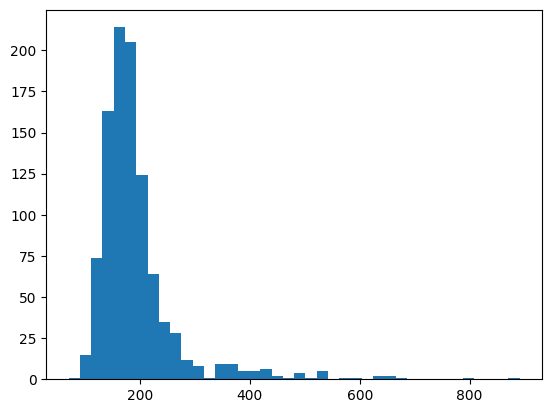

In [52]:
plt.hist(lengths,bins=40)